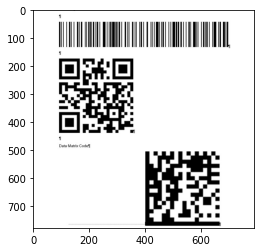

In [1]:
# import the necessary packages
import matplotlib.pyplot as plt
import cv2
 
# Business as usual: read image and visualise it
bgr = cv2.imread('images/code.jpg')

rgb = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)

plt.imshow(rgb)


# ZBar
Fortunately, we don't have to start from scratch when reading barcodes. We can implement methods that are freely available already. A well-known library for deciphering various codes (e.g. barcode, datamatrix, QR code) is ZBar. For further experiments we use the Python implementation of it, `pyzbar`.

We get access to those functions by importing `pyzbar`:

In [2]:
# Import library to read barcodes
import pyzbar.pyzbar as pyzbar

ImportError: Unable to find zbar shared library

Next, we run the `decode()` function on the image. `decode()` returns detected objects encapsulating information about the objects, such as code type, payload (i.e. data) and its position.

In [3]:
objs = pyzbar.decode(rgb)

for obj in objs:
    print('type:', obj.type)
    print('data:', obj.data)
    print('position:', obj.polygon)

NameError: name 'pyzbar' is not defined

How many codes were detected? Why?

# Optional
- Can you create a function that calculates the barcode area in square pixels?
- Can you create a function that draws the barcode onto the input image?

In [33]:
def get_area(obj):
    return obj.rect.width * obj.rect.height

In [34]:
get_area(objs[0])

68121

In [41]:
def draw_rect(image, rectangle):
    # Start coordinate, here (5, 5) 
    # represents the top left corner of rectangle 
    start_point = (rectangle.left, rectangle.top) 

    # Ending coordinate, here (220, 220) 
    # represents the bottom right corner of rectangle 
    end_point = (rectangle.left + rectangle.width,
                 rectangle.top + rectangle.height) 

    # Blue color in BGR 
    color = (255, 0, 0) 

    # Line thickness of 2 px 
    thickness = 2

    # Using cv2.rectangle() method 
    # Draw a rectangle with blue line borders of thickness of 2 px 
    image = cv2.rectangle(image, start_point, end_point, color, thickness) 

    # Displaying the image  
    plt.imshow(image)  

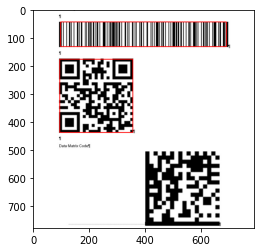

In [43]:
draw_rect(rgb, objs[1].rect)